In [3]:
%pip install pandas numpy seaborn scikit-learn matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Modeller och verktyg
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# ---------------------------------------------------------
# STEG 1: Ladda och Förstå datan
# ---------------------------------------------------------
# Ladda datasetet
X, y = load_diabetes(return_X_y=True, as_frame=True)

# Datasetet är redan skalat (normaliserat) i Scikit-Learn, vilket är bra att veta!
print(f"Antal rader: {X.shape[0]}")
print(f"Antal features: {X.shape[1]}")

  Using cached numpy-2.4.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.7 MB 11.8 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.7 MB 14.5 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.7 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 15.2 MB/s eta 0:0


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Antal rader: 442
Antal features: 10


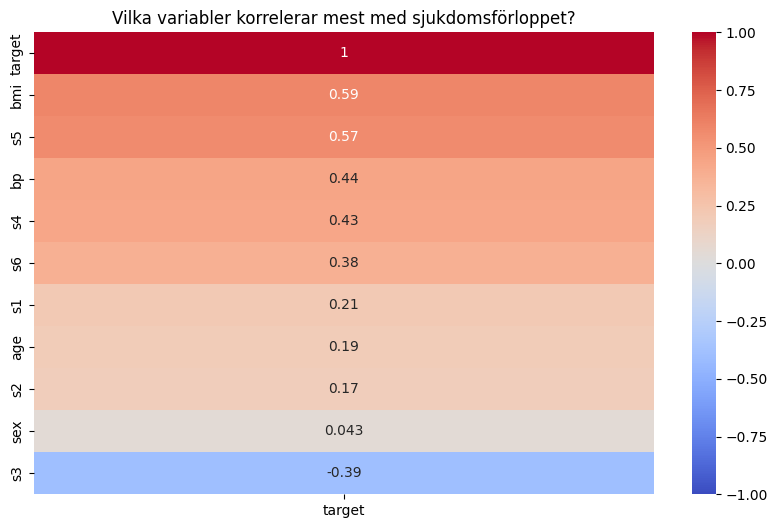

In [4]:
# Titta på korrelationer - Vad påverkar sjukdomen (target) mest?
# Vi slår ihop X och y tillfälligt för att göra en korrelationsmatris
full_data = X.copy()
full_data['target'] = y
correlation = full_data.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation[['target']].sort_values(by='target', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Vilka variabler korrelerar mest med sjukdomsförloppet?")
plt.show()

In [ ]:
# ---------------------------------------------------------
# STEG 2: Dela upp data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# STEG 3: Det grundläggande flödet (Linear Regression)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Prediktion och Utvärdering
y_pred_lr = model_lr.predict(X_test)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Resultat: Linjär Regression (Baslinje) ---")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R^2:  {r2_lr:.2f}")


--- Resultat: Linjär Regression (Baslinje) ---
RMSE: 53.85
R^2:  0.45


In [19]:
# ---------------------------------------------------------
# STEG 4: Försök till förbättring (Random Forest)
# ---------------------------------------------------------
# Diabetes-datasetet är ganska litet (442 rader) och brusigt. 
# Ibland är enkla modeller bäst, men vi testar en Random Forest för att se om vi kan fånga icke-linjära samband.
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- Resultat: Random Forest (Mer komplex) ---")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R^2:  {r2_rf:.2f}")


--- Resultat: Random Forest (Mer komplex) ---
RMSE: 53.68
R^2:  0.46


In [20]:
# ---------------------------------------------------------
# STEG 5: Jämförelse och Slutsats
# ---------------------------------------------------------
if rmse_lr < rmse_rf:
    print("\n-> Slutsats: Linjär Regression vann! Datan är troligen ganska linjär eller för liten för komplexa modeller.")
    best_model = model_lr
else:
    print("\n-> Slutsats: Random Forest vann! Det finns komplexa samband i datan.")
    best_model = model_rf

# Visa vad som styrde mest (Feature Importance för Random Forest är lätt att tolka)
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]
print("\nViktigaste variablerna (enligt Random Forest):")
for i in range(5):
    print(f"{X.columns[indices[i]]}: {importances[indices[i]]:.3f}")


-> Slutsats: Random Forest vann! Det finns komplexa samband i datan.

Viktigaste variablerna (enligt Random Forest):
bmi: 0.423
s5: 0.268
bp: 0.078
s6: 0.056
s2: 0.041
